<a href="https://colab.research.google.com/github/jyryu3161/2026_abp/blob/main/Lab02_MDMX_denovo_binder_design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **실습. p53–MDMX 결합을 막는 펩타이드를 처음부터 설계하기**


---

### 이 실습에서 배우는 것

1. **AlphaFold hallucination**으로 표적에 붙는 펩타이드의 **Backbone** 생성한다.
2. **ProteinMPNN**으로 backbone에 맞는 아미노산 서열 후보를 여러개 뽑는다.
3. **self-consistency 검증**으로 설계 결과를 검증한다.

---

### p53는 어떻게 조절되고, 우리는 어디에 끼어드는가

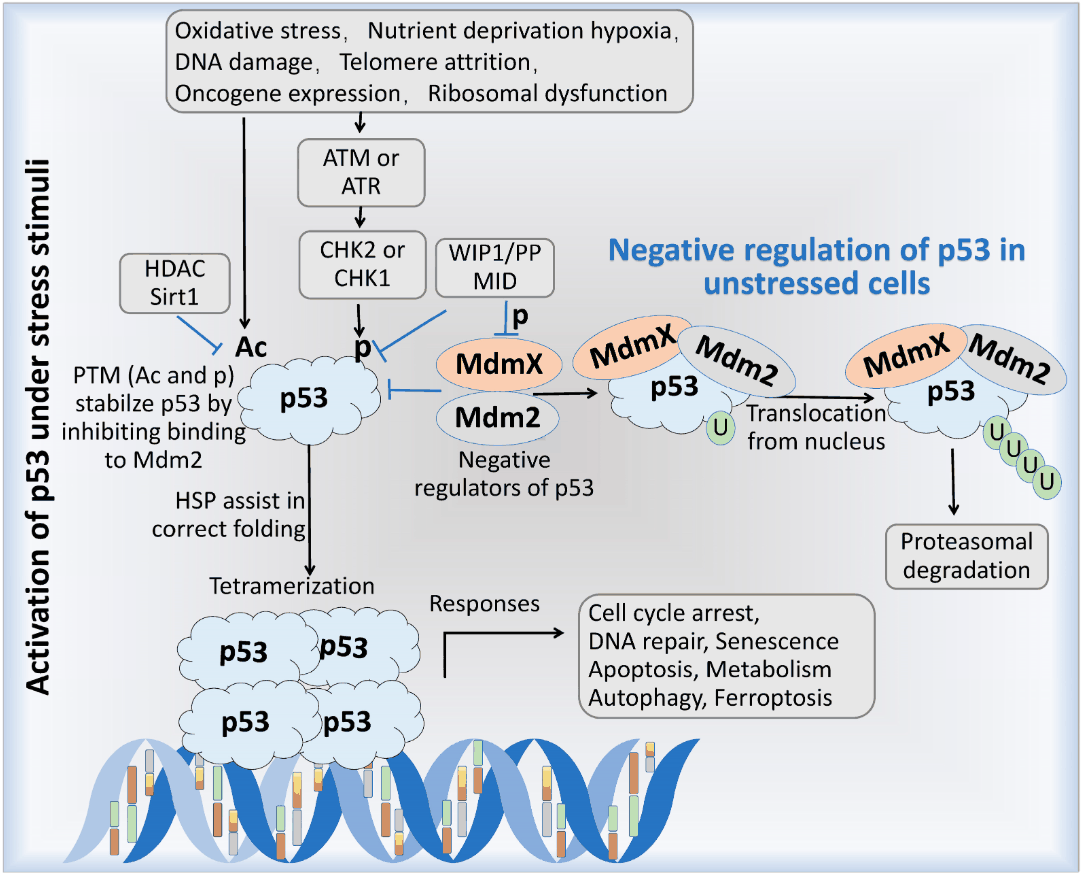

**Cells** *2025;14(8):583.* [doi:10.3390/cells14080583](https://doi.org/10.3390/cells14080583) *(CC BY 4.0)*


**Stress stimuili**(DNA damage, oxidation, Oncogen expression,etc)가 감지되면 ATM/ATR → CHK1/CHK2 경로를 거쳐
p53가 **안정화**됩니다.  
안정화된 p53는 tetramer를 형성할 수 있고, cell cycle arrest · DNA repair · apoptosis를 유도해 스트레스로 부터 우리 몸을 보호합니다.

unstressed 상태에서는 **MdmX와 Mdm2가 p53에 붙어** 불필요한 반응을 막습니다.

하지만 암세포의 약 50%는 MDM2/MDMX가 과발현되어 정상적인 스트레스 대응이 불가능합니다. peptide design을 통해 **MDM2/MDMX의 binding site를 막을 수만 있다면** p53이 풀려나 암세포를 죽일 수 있습니다. 이것은 실제 항암 신약 전략이고, nutlin 계열 저해제와
stapled peptide(예: ALRN-6924)가 이 원리로 개발되었습니다.



우리가 쓸 구조 **4N5T**는 **MDMX(MDM4)** 단백질에 p53 유래 펩타이드가 붙어 있는 복합체입니다.

- Target: MDMX SWIB 도메인, **90 residue** (작아서 계산이 가볍습니다)
- 정답 펩타이드: ATSP-7041 — 실제 전임상까지 간 stapled peptide

> **오늘의 규칙:** 정답 펩타이드의 **서열은 설계에 쓰지 않습니다.**
> Target의 "어디 부분에 붙어야 하는지"에 대한 정보만 가져오고, 서열은 **채점할 때만** 꺼내 봅니다.
> 이것을 **known epitope / unknown binder** 설정이라고 하며, 실제 신약 개발과 같은 구도입니다.
___

## 배경
---

단백질 설계에 활용되는 대표적인 2가지 도구가 있습니다.

$$\text{AlphaFold: } \text{Sequence} \rightarrow \text{Structure}
\qquad\qquad
\text{ProteinMPNN: }  P(\text{Sequence|Structure})$$



| | AfDesign (AlphaFold 기반) | ProteinMPNN |
|---|---|---|
| 하는 일 | 구조와 서열을 **동시에** 탐색 | 구조를 **고정**하고 서열만 |
| 속도 | 느림 (step마다 AlphaFold 실행) | 매우 빠름 (초 단위) |
| 결과 | 그럴듯한 backbone 1개 | 그 backbone에 맞는 서열 수십 개 |
| 약점 | 서열이 거칠다 (poly-G 등) | 구조를 만들어내지는 못한다 |


> 두 도구의 약점을 보완하기 위해서 AfDesign으로 **Backbone**을 만들고 → ProteinMPNN으로 **Sequence** 후보를 뽑는 전략으로 진행됩니다.

In [ ]:
#@title 0. GPU 확인
import os, subprocess, sys, platform
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
try:
    out = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"], text=True)
    print("GPU:", out.strip())
except Exception:
    print("GPU가 감지되지 않았습니다.")
    print("Colab 메뉴: Runtime > Change runtime type > T4 GPU 를 선택하세요.")

Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
GPU: Tesla T4, 15360 MiB


## 1. 실행 모드와 소요 시간

표적이 90 residue로 작아서 무료 Colab T4에서도 충분히 돌아갑니다.

**실측 (Tesla T4, FAST 모드)**

| 단계 | 시간 |
|---|---|
| 모델 설치 (최초 1회) | 약 5 분 |
| 설계 (AfDesign) | 약 5 분 |
| 서열 생성 (ProteinMPNN, 32개) | 약 30 초 |
| 검증 (AlphaFold 재예측 12개) | 약 1 분 |
| **전체** | **약 12 분** |

In [ ]:
#@title 1. 실습 설정
FAST_MODE = True         #@param {type:"boolean"}
RANDOM_SEED = 0          #@param {type:"integer"}
BINDER_LENGTH = 14       #@param {type:"integer"}
N_MPNN = 32              #@param {type:"integer"}
MPNN_TEMPERATURE = 0.1   #@param {type:"number"}
CONTACT_CUTOFF = 5.0     #@param {type:"number"}
N_HOTSPOT = 6            #@param {type:"integer"}

# 설계 강도: (soft_iters, hard_iters)
#   soft  = gradient 기반 탐색 (연속 완화 상태)
#   hard  = semi-greedy 돌연변이 탐색 (실제 아미노산으로 확정한 뒤)
if FAST_MODE:
    SOFT_ITERS, HARD_ITERS = 50, 16
else:
    SOFT_ITERS, HARD_ITERS = 120, 32

# self-consistency 통과 기준 (실무에서 흔히 쓰는 값)
PASS_RMSD  = 2.0    # 설계한 모양에서 얼마나 벗어났나 (A, 낮을수록 좋음)
PASS_PLDDT = 0.70   # 구조 확신도 (0~1, 높을수록 좋음)
PASS_IPTM  = 0.50   # 두 chain의 상대 배치 확신도 (0~1, 높을수록 좋음)

print(f"설계 파라미터   : soft {SOFT_ITERS} + semigreedy {HARD_ITERS}")
print(f"binder 길이 : {BINDER_LENGTH} aa")
print(f"MPNN 후보   : {N_MPNN}개 (temperature {MPNN_TEMPERATURE})")
print(f"합격 기준   : scRMSD < {PASS_RMSD} A, pLDDT > {PASS_PLDDT}, ipTM > {PASS_IPTM}")

설계 파라미터   : soft 50 + semigreedy 16
binder 길이 : 10 aa
MPNN 후보   : 32개 (temperature 0.1)
합격 기준   : scRMSD < 2.0 A, pLDDT > 0.7, ipTM > 0.5


## 2. 환경 설치


In [ ]:
#@title 2a. 패키지 설치
print("최초 실행 시 약 5분 소요")
!pip -q install --no-deps "git+https://github.com/sokrypton/ColabDesign.git"
!pip -q install py3Dmol absl-py biopython chex dm-haiku dm-tree immutabledict ml-collections optax joblib pandas matplotlib scipy

# AlphaFold parameters
import os, pathlib
pathlib.Path("params").mkdir(exist_ok=True)
if not pathlib.Path("params/params_model_1_ptm.npz").exists():
    !curl -fsSL https://storage.googleapis.com/alphafold/alphafold_params_2022-12-06.tar | tar x -C params

print("설치 완료")

최초 실행 시 약 5분 소요
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.
설치 완료


###2b. ColabDesign <-> 최신 JAX 호환 패치

최신 jax에서는 ColabDesign이 아직 쓰는 두 API가 제거되어 설계 셀에서 에러가 납니다.

| 제거된 API | 증상 |
|---|---|
| `jax.lib.xla_bridge` | `AttributeError: module 'jax.lib' has no attribute 'xla_bridge'` |
| `jnp.clip(a_min=, a_max=)` | `TypeError: clip() got an unexpected keyword argument 'a_max'` |

에러를 방지하기 위해서 패치를 진행합니다.

In [ ]:
import gc, jax, jax.numpy as jnp

def install_colabdesign_compat(verbose=True):
    patched = {}
    if hasattr(jax.lib, "xla_bridge"):
        patched["clear_mem"] = False
    else:
        from jax.extend.backend import get_backend
        def clear_mem():
            try:
                backend = get_backend()
                if hasattr(backend, "live_buffers"):
                    for buf in backend.live_buffers():
                        buf.delete()
            except Exception:
                pass
            gc.collect()
        import importlib
        import colabdesign.shared.utils as _u
        _u.clear_mem = clear_mem
        for _m in ("colabdesign", "colabdesign.af", "colabdesign.mpnn", "colabdesign.tr"):
            try:
                setattr(importlib.import_module(_m), "clear_mem", clear_mem)
            except Exception:
                pass
        patched["clear_mem"] = True

    try:
        jnp.clip(jnp.zeros(1), a_min=0, a_max=1)
        patched["jnp.clip"] = False
    except TypeError:
        _orig = jnp.clip
        def clip(x, min=None, max=None, a_min=None, a_max=None, **kw):
            return _orig(x, min if min is not None else a_min,
                            max if max is not None else a_max, **kw)
        jnp.clip = clip
        patched["jnp.clip"] = True

    if verbose:
        print("jax:", jax.__version__)
        for k, v in patched.items():
            print(f"  {k:10s}: {'패치 적용' if v else '패치 불필요'}")
    return patched

install_colabdesign_compat()

jax: 0.11.1
  clear_mem : 패치 적용
  jnp.clip  : 패치 적용


{'clear_mem': True, 'jnp.clip': True}

In [ ]:
#@title 2c. GPU 사용 확인
# jax가 GPU를 못 잡으면 에러가 나지 않고 조용히 CPU로 계산합니다.
# GPU가 없다면 afdesign 설계만 몇 시간씩 걸리기 때문에 재확인합니다.

import sys, importlib.util, jax

devices = jax.devices()
on_gpu  = any(d.platform == "gpu" for d in devices)
has_plugin = importlib.util.find_spec("jax_plugins") is not None or \
             importlib.util.find_spec("jax_cuda12_plugin") is not None

print("python  :", sys.executable)
print("jax     :", jax.__version__)
print("devices :", devices)
print("cuda plugin 설치됨:", has_plugin)

if on_gpu:
    print("\nGPU 사용 가능 - 계속 진행하세요.")
else:
    raise RuntimeError(
        "jax가 GPU를 잡지 못했습니다. 여기서 중단합니다.\n\n"
    )

python  : /usr/bin/python3
jax     : 0.11.1
devices : [CudaDevice(id=0)]
cuda plugin 설치됨: True

GPU 사용 가능 - 계속 진행하세요.


In [ ]:
#@title 2d. 그림 스타일 + 다이어그램 도구
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ_BLUE = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
            "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
CMAP_SEQ  = LinearSegmentedColormap.from_list("seq",  SEQ_BLUE)
CMAP_SEQ0 = LinearSegmentedColormap.from_list("seq0", ["#fcfcfb"] + SEQ_BLUE)
CMAP_NEAR = LinearSegmentedColormap.from_list("near", SEQ_BLUE[::-1] + ["#fcfcfb"])
CMAP_SEQ_MID = LinearSegmentedColormap.from_list(
    "seq_mid", ["#f2f8f6", "#9ed9c4", "#1baf7a", "#2a78d6", "#1c5cab", "#0d366b"])
CMAP_DIST = LinearSegmentedColormap.from_list(
    "dist", ["#a11414", "#e34948", "#2a78d6", "#9ec5f4", "#fcfcfb"])
INK, INK2, SURFACE, GRID = "#0b0b0b", "#52514e", "#fcfcfb", "#e8e7e3"

plt.rcParams.update({"figure.facecolor": SURFACE, "savefig.facecolor": SURFACE,
                     "font.size": 10, "axes.titlesize": 12,
                     "axes.titleweight": "bold", "figure.dpi": 110})

def style_axes(ax, grid_axis="y"):
    ax.set_facecolor(SURFACE)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#d5d4d0"); ax.spines[s].set_linewidth(0.8)
    if grid_axis:
        ax.grid(True, axis=grid_axis, color=GRID, linewidth=0.8, linestyle="-")
        ax.set_axisbelow(True)
    ax.tick_params(colors=INK2, labelsize=9, length=3, width=0.8)
    ax.title.set_color(INK)
    ax.xaxis.label.set_color(INK2); ax.yaxis.label.set_color(INK2)
    return ax

def bare_colorbar(fig, im, ax, label):
    cb = fig.colorbar(im, ax=ax, pad=0.02)
    cb.set_label(label, color=INK2, fontsize=9)
    cb.ax.tick_params(colors=INK2, labelsize=8); cb.outline.set_visible(False)
    return cb

print("그림 스타일 설정 완료")

그림 스타일 설정 완료


### 실습 전체 흐름

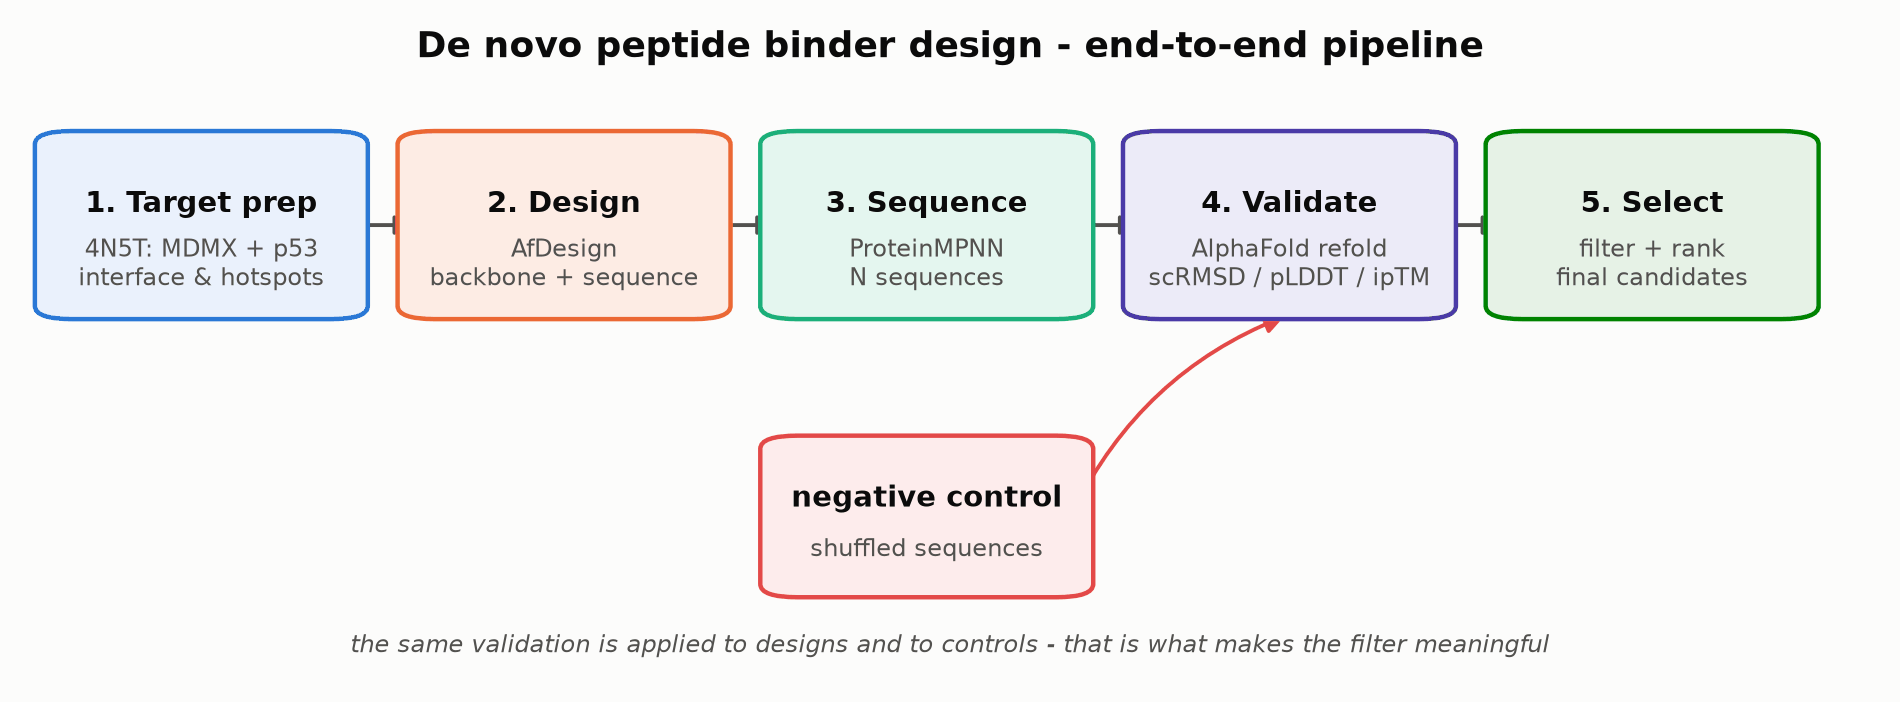

2~4단계가 이 실습의 핵심 루프입니다.
특히 **4단계(검증)를 3단계 결과뿐 아니라 '랜덤 서열로 만든 대조군'에도 똑같이 적용**하여 비교합니다.

## 3. 표적 준비 — 어디에 붙일 것인가

설계를 시작하기 전에 **"Target Binding site** 를 정해야 합니다.
4N5T에는 이미 펩타이드가 붙어 있으므로, 그 펩타이드가 닿는 자리를 계산해서
목표 지점(**hotspot**)으로 삼습니다. 여기서 가져오는 것은 **위치 정보뿐**입니다. 펩타이드의 **서열은 쓰지 않습니다.**

> **참고:** MDMX는 원래 490개 아미노산짜리 단백질이지만, 우리는 90개짜리 조각만 씁니다.  
> MDMX 단백질 중에 p53이 붙는 부분(SWIB 도메인)만 따로 결정화한 것이 4N5T입니다.

In [ ]:
#@title  구조 분석용 공통 함수
from Bio.PDB import PDBParser, PDBIO, Select, NeighborSearch
from Bio.SeqUtils import seq1
from pathlib import Path
from urllib.request import urlretrieve
import numpy as np, pandas as pd, copy

parser = PDBParser(QUIET=True)

def download_pdb(pdb_id, outfile=None):
    pdb_id = pdb_id.upper()
    outfile = outfile or f"{pdb_id}.pdb"
    if not Path(outfile).exists():
        urlretrieve(f"https://files.rcsb.org/download/{pdb_id}.pdb", outfile)
    return outfile

def pdb_chain_table(pdb_file):
    mols, cur = {}, None
    for line in open(pdb_file):
        if not line.startswith("COMPND"): continue
        body = line[10:].strip()
        if body.startswith("MOLECULE:"):
            cur = body[len("MOLECULE:"):].strip().rstrip(";")
        elif body.startswith("CHAIN:") and cur is not None:
            for c in body[len("CHAIN:"):].strip().rstrip(";").split(","):
                mols[c.strip()] = cur
        elif cur is not None and not any(body.startswith(k) for k in
                ("MOL_ID:", "SYNONYM:", "ENGINEERED:", "EC:", "FRAGMENT:", "MUTATION:", "OTHER_DETAILS:")):
            cur = (cur + " " + body.rstrip(";")).strip()
    return mols

def chain_residues(structure, chain_id):
    # 표준 아미노산이면서 CA를 가진 residue만. (물·리간드·비표준 잔기는 제외됩니다)
    return [r for r in structure[0][chain_id] if r.id[0] == " " and "CA" in r]

def chain_hetero(structure, chain_id):
    # 같은 chain 안의 비표준 residue (변형 아미노산, 캡, 링커 등). 물은 제외.
    return [r for r in structure[0][chain_id]
            if r.id[0] not in (" ", "W") and r.get_resname() != "HOH"]

def chain_sequence(structure, chain_id):
    out = []
    for r in chain_residues(structure, chain_id):
        try: out.append(seq1(r.resname) or "X")
        except Exception: out.append("X")
    return "".join(out)

def min_distance_matrix(structure, chain_a, chain_b):
    A, B = chain_residues(structure, chain_a), chain_residues(structure, chain_b)
    ca = [np.array([a.coord for a in r.get_atoms()]) for r in A]
    cb = [np.array([a.coord for a in r.get_atoms()]) for r in B]
    D = np.zeros((len(A), len(B)))
    for i, xi in enumerate(ca):
        for j, xj in enumerate(cb):
            D[i, j] = np.sqrt(((xi[:, None, :] - xj[None, :, :]) ** 2).sum(-1)).min()
    return D, np.array([r.id[1] for r in A]), np.array([r.id[1] for r in B])

def interface_from_matrix(D, a_numbers, a_resnames, cutoff=5.0):
    #   min_distance = 가장 가까운 원자쌍 거리
    #   n_partners   = cutoff 이내 상대 residue 수 (클수록 interface의 핵심)
    mind, npart = D.min(axis=1), (D < cutoff).sum(axis=1)
    m = npart > 0
    return pd.DataFrame({"resseq": a_numbers[m], "resname": np.array(a_resnames)[m],
                         "min_distance": mind[m].round(2), "n_partners": npart[m]}).reset_index(drop=True)

class NotDisordered(Select):
    def accept_atom(self, atom):
        return (not atom.is_disordered()) or atom.get_altloc() in (" ", "A")

def save_single_chain(structure, chain_id, outfile, new_chain="A"):
    # chain 하나만 남긴 PDB 저장.
    # 주의: 다른 chain을 먼저 detach해야 "id 'A' is already used" ValueError를 피합니다.
    st = copy.deepcopy(structure); model = st[0]
    for ch in list(model):
        if ch.id != chain_id: model.detach_child(ch.id)
    if new_chain and new_chain != chain_id: model[chain_id].id = new_chain
    io = PDBIO(); io.set_structure(st); io.save(outfile, NotDisordered())
    n = len(chain_residues(st, new_chain or chain_id))
    print("saved:", outfile, "| residues:", n)
    return n

print("공통 함수 로드 완료")

공통 함수 로드 완료


### interface를 정의한다는 것

두 Chain이 **"닿아 있다"**는 것을 컴퓨터에게 알려주려면 기준이 필요합니다. 이 실습에서는 **거리 기준**을 씁니다.

> 두 residue의 **가장 가까운 원자쌍 거리**가 5 Å 이내면 접촉으로 봅니다. 이는 van der Waals 과 H bond 거리를 포괄하는 관습적인 값입니다.

<br>

**hotspot**은 그중에서도 접촉이 가장 많은 residue들입니다.
AfDesign에게 "아무 데나 붙지 말고 여기 근처에 붙어라"라고 지시하는 데 씁니다.

hostpot은 여러개 있을 수 있지만 우리는 그 중에서도 일부만을 지정해줄 것입니다.
> 5 Å 내의 residue 전부를 input으로 주면 최적화가 한 포켓에 집중하지 못합니다.   
> AfDesign 관례는 3~10개입니다.

In [ ]:
#@title 3a. 4N5T 다운로드 + 표적/펩타이드 확인 + target.pdb 분리
pdb_file = download_pdb("4N5T")
structure = parser.get_structure("4N5T", pdb_file)

TARGET_CHAIN  = "A"   # MDMX
PEPTIDE_CHAIN = "B"   # p53 유래 펩타이드

mols = pdb_chain_table(pdb_file)
rows = []
for ch in structure[0]:
    res = chain_residues(structure, ch.id)
    if not res: continue
    name = mols.get(ch.id, "?")
    rows.append({"chain": ch.id, "molecule": (name[:45]+"...") if len(name) > 48 else name,
                 "N_residues": len(res)
                 })
display(pd.DataFrame(rows))

Dmin, tnum, pnum = min_distance_matrix(structure, TARGET_CHAIN, PEPTIDE_CHAIN)
target_res = chain_residues(structure, TARGET_CHAIN)
pep_res = chain_residues(structure, PEPTIDE_CHAIN)
resnames = [r.resname for r in target_res]
contacts = interface_from_matrix(Dmin, tnum, resnames, cutoff=CONTACT_CUTOFF)

chosen = (contacts.sort_values("n_partners", ascending=False).head(N_HOTSPOT)
          if N_HOTSPOT and N_HOTSPOT < len(contacts) else contacts).sort_values("resseq")
hotspots = chosen["resseq"].astype(int).tolist()
HOTSPOT_STR = ",".join(map(str, hotspots))


save_single_chain(structure, TARGET_CHAIN, "target.pdb", new_chain="A")

,chain,molecule,N_residues
0,A,PROTEIN MDM4,90
1,B,ATSP-7041 STAPLED-PEPTIDE,11


saved: target.pdb | residues: 90


90

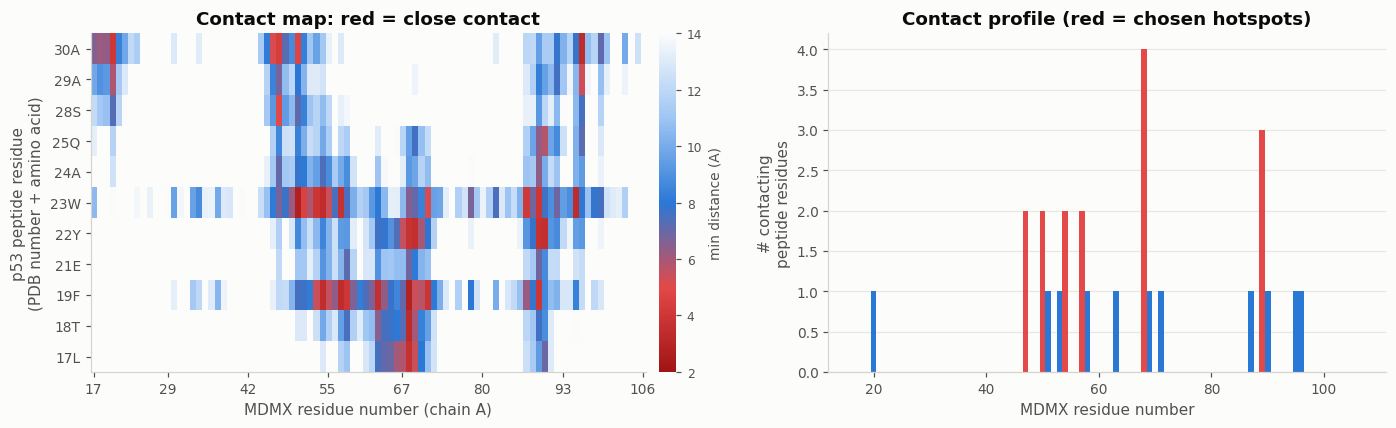



5.0 A 이내 interface residues


,resseq,resname,min_distance,n_partners
9,68,GLN,2.81,4
13,89,VAL,3.69,3
6,57,ILE,3.41,2
1,47,LYS,4.41,2
2,50,MET,2.75,2
5,54,GLY,3.41,2
0,20,GLU,4.05,1
4,53,LEU,3.96,1
3,51,HIS,4.63,1
8,63,TYR,3.64,1



Hotspot (6개): 47,50,54,57,68,89


In [ ]:
#@title 3b. Hotspot이 어디인가?
pep_labels = [f"{n}{seq1(r.resname) or 'X'}" for n, r in zip(pnum, pep_res)]

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.0),
                         gridspec_kw={"width_ratios": [1.2, 1.0]})
ax = axes[0]
im = ax.imshow(np.clip(Dmin, 0, 14).T, aspect="auto", origin="lower",
               cmap=CMAP_DIST, vmin=2, vmax=14, interpolation="nearest")
ax.set_yticks(range(len(pep_labels)))
ax.set_yticklabels(pep_labels, fontsize=8)
xt = np.linspace(0, len(tnum)-1, 8).astype(int)
ax.set_xticks(xt); ax.set_xticklabels(tnum[xt], fontsize=8)
ax.set_xlabel("MDMX residue number (chain A)")
ax.set_ylabel("p53 peptide residue\n(PDB number + amino acid)")
ax.set_title("Contact map: red = close contact")
bare_colorbar(fig, im, ax, "min distance (A)")
style_axes(ax, grid_axis=None)

ax = axes[1]
ncon = (Dmin < CONTACT_CUTOFF).sum(axis=1)
cols = [PALETTE[7] if n in hotspots else PALETTE[0] for n in tnum]
ax.bar(tnum, ncon, width=1.0, color=cols, linewidth=0)
ax.set_xlabel("MDMX residue number"); ax.set_ylabel("# contacting\npeptide residues")
ax.set_title("Contact profile (red = chosen hotspots)")
style_axes(ax)
fig.tight_layout(); plt.show()

print(f"\n\n{CONTACT_CUTOFF} A 이내 interface residues")
display(contacts.sort_values("n_partners", ascending=False).head(10))
print(f"\nHotspot ({len(hotspots)}개):", HOTSPOT_STR)

In [ ]:
#@title 3c. 3D Complex 확인
import py3Dmol
view = py3Dmol.view(width=880, height=520)
view.addModel(open(pdb_file).read(), "pdb")

view.setStyle({}, {})
view.setStyle({"chain": TARGET_CHAIN},  {"cartoon": {"color": "lightgray", "opacity": 0.6}})
view.addSurface(py3Dmol.VDW,
                {"opacity": 0.80, "color": "#d8d8d8"},
                {"chain": TARGET_CHAIN})

view.addSurface(py3Dmol.VDW,
                {"opacity": 0.90, "color": "#e34948"},
                {"chain": TARGET_CHAIN, "resi": hotspots})

view.setStyle({"chain": PEPTIDE_CHAIN}, {"cartoon": {"color": "orange"},
                                         "stick": {"radius": 0.20}})
view.zoomTo({"chain": PEPTIDE_CHAIN})
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.


**회색** = MDMX  
**빨간색** = hotspot  
**주황색** = p53 유래 펩타이드  
<br>
펩타이드의 큰 곁사슬(Phe19, Trp23)이 표면에 파인 '구멍'에 꽂혀 있습니다.  
이 구멍들이 우리가 채워야 할 포켓이고, 설계의 목표 지점입니다.

## 4. 설계 — AlphaFold를 거꾸로 돌리기

AlphaFold는 원래 *서열 → 구조* 예측기입니다.  
"원하는 구조적 성질"을 최적화 할 값(loss)으로 정하고, Alphafold를 활용해서 이 값을 찾아가는 방식을 **hallucination**이라 합니다.

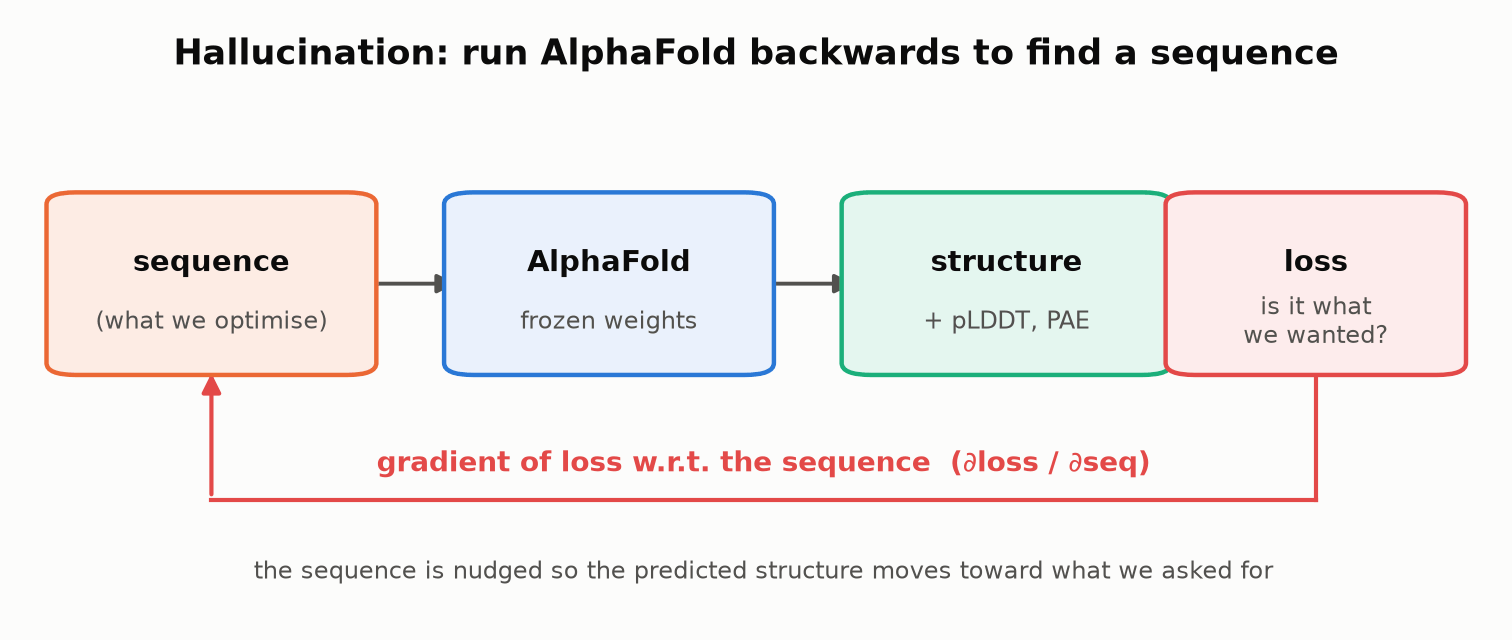

**입력 서열**을 바꿔가며 원하는 구조가 나오도록 하는 서열의 확률을 높여줍니다.

### loss란 무엇인가?

"좋은 binder"를 숫자로 정의한 것이 loss입니다. 주요 항은 다음과 같습니다.

| loss 항 | 효과 |
|---|---|
| `plddt` | binder 자체가 접힌 구조를 갖도록 |
| `i_con` | binder가 표적과 **접촉**하도록|
| `con` | binder 내부 접촉하도록 |
| `i_pae` | 표적 대비 binder 위치가 더 높은 confidence로 붙도록 |
| `seq_ent` | 서열이 한 글자로 수렴하도록 |

`hotspot`을 주면 `i_con`이 **그 residue 근처의 접촉만** 세도록 제한됩니다.

In [ ]:
#@title 4a. AfDesign 실행 - 약 7분 소요
import time
from colabdesign import mk_afdesign_model, clear_mem

clear_mem()
af_model = mk_afdesign_model(protocol="binder", data_dir=".",
                             num_recycles=0, recycle_mode="sample")
print("AF2 models:", af_model._model_names)

af_model.prep_inputs(pdb_filename="target.pdb", chain="A",
                     binder_len=BINDER_LENGTH, hotspot=HOTSPOT_STR)
print("target / binder length:", af_model._lengths,
      "-> AF2가 보는 총 길이:", sum(af_model._lengths))

af_model.restart(seed=RANDOM_SEED, rm_aa="C")   # C 제외: 원치 않는 이황화결합 방지

_t0 = time.time()
af_model.design_pssm_semigreedy(soft_iters=SOFT_ITERS, hard_iters=HARD_ITERS, verbose=0)
print(f"\n설계 소요 시간: {time.time()-_t0:.0f}초")

AFDESIGN_SEQ = af_model.get_seq()[0]
_log = af_model._tmp["log"][-1]
print("AfDesign 서열:", AFDESIGN_SEQ)
print("설계 지표:", {k: round(float(_log[k]), 3) for k in ["plddt", "ptm", "i_ptm"] if k in _log})

af_model.save_pdb("design.pdb")
print("saved: design.pdb  (표적 chain A + 설계 binder chain B)")

AF2 models: ['model_1_ptm', 'model_2_ptm']
target / binder length: [90, 10] -> AF2가 보는 총 길이: 100

설계 소요 시간: 402초
AfDesign 서열: EFVQWFVDNI
설계 지표: {'plddt': 0.927, 'ptm': 0.875, 'i_ptm': 0.862}
saved: design.pdb  (표적 chain A + 설계 binder chain B)


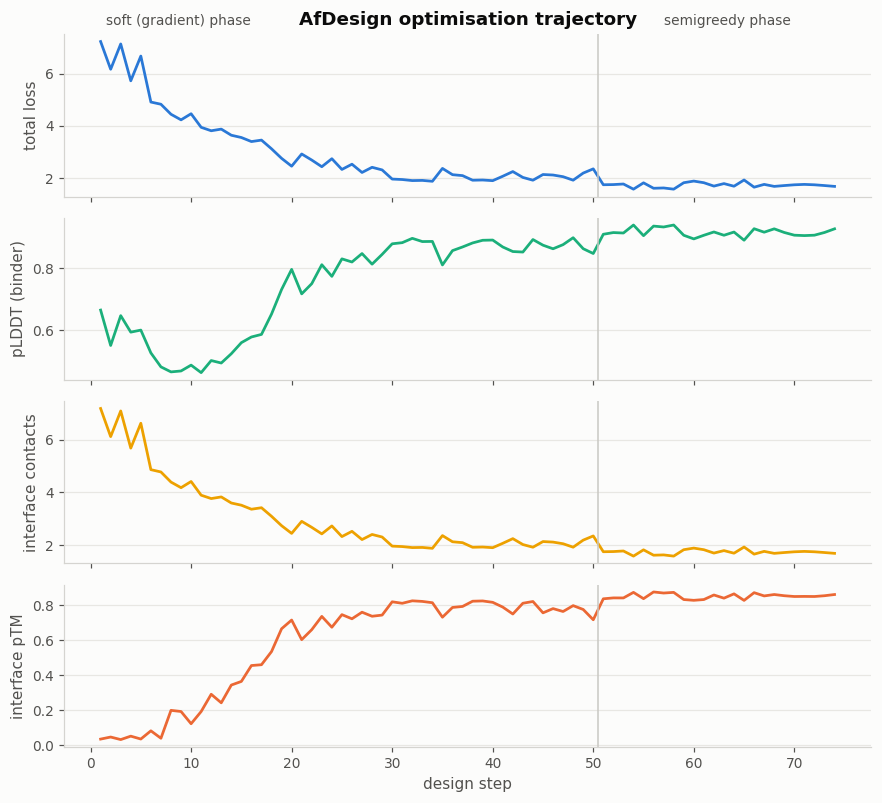

In [ ]:
#@title 4b. 최적화 궤적
log = af_model._tmp["log"]
steps = np.arange(1, len(log) + 1)
panels = [("loss",  "total loss",         PALETTE[0]),
          ("plddt", "pLDDT (binder)",     PALETTE[2]),
          ("i_con", "interface contacts", PALETTE[3]),
          ("i_ptm", "interface pTM",      PALETTE[1])]

fig, axes = plt.subplots(len(panels), 1, figsize=(8.2, 7.4), sharex=True)
for ax, (key, label, col) in zip(axes, panels):
    if key not in log[0]: continue
    ax.plot(steps, [l[key] for l in log], color=col, linewidth=1.8)
    ax.set_ylabel(label)
    if SOFT_ITERS < len(log):
        ax.axvline(SOFT_ITERS + 0.5, color="#c9c8c3", linewidth=1)
    style_axes(ax)
axes[0].set_title("AfDesign optimisation trajectory")
axes[-1].set_xlabel("design step")
if SOFT_ITERS < len(log):
    axes[0].text(SOFT_ITERS + 7, 1.04, "semigreedy phase",
                 transform=axes[0].get_xaxis_transform(), fontsize=9, color=INK2, va="bottom")
    axes[0].text(1.5, 1.04, "soft (gradient) phase",
                 transform=axes[0].get_xaxis_transform(), fontsize=9, color=INK2, va="bottom")
fig.tight_layout(); plt.show()

세로선 이후가 semigreedy 구간입니다. 여기서는 seed 서열을 확정된 뒤 Mutation을 주는 방식으로 진행됩니다.

### pLDDT, PAE, ipTM

| 지표 | 범위 | 답하는 질문 | 단위 |
|---|---|---|---|
| **pLDDT** | 0~100 | 이 **residue 하나**의 국소 구조가 맞나? | residue별 |
| **PAE** | 0~31 Å | residue *i* 기준으로 볼 때 *j*의 **위치 오차**는? | residue 쌍 |
| **ipTM** | 0~1 | 두 사슬의 **상대적 배치** 전체가 맞나? | 복합체당 |

> **pLDDT가 높아도 ipTM은 낮을 수 있습니다.**
> 펩타이드가 예쁜 나선으로 접혔지만(pLDDT 높음), 표적의 *어디에* 붙는지는 모르는 상태(ipTM 낮음)가 흔합니다.

binder 설계에서 실제로 봐야 하는 것은 **interface 지표(ipTM, interface PAE)** 입니다.

| ipTM | 해석 |
|---|---|
| > 0.8 | 매우 확신 |
| 0.6 ~ 0.8 | 그럴듯함 |
| 0.4 ~ 0.6 | 불확실 |
| < 0.4 | 사실상 근거 없음 |

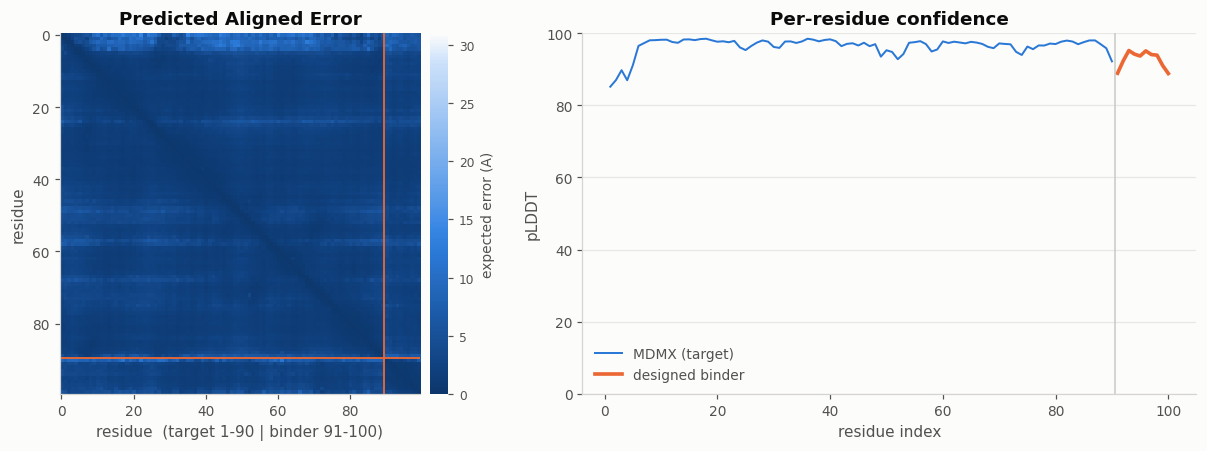

binder 평균 pLDDT    : 92.7
binder 내부 평균 PAE : 1.2 A   <- 이 값이 낮으면 잘 접혀있다는 의미함
interface 평균 PAE   : 3.0 A   <- 이 값이 낮으면 Target에 정확히 붙었다는 의미함



In [ ]:
#@title 4c. [그림] PAE와 pLDDT로 설계 진단하기
aux = af_model._tmp["best"].get("aux", af_model.aux)
tL, bL = af_model._lengths
pae = np.asarray(aux["pae"])
plddt = np.asarray(aux["plddt"]);  plddt = plddt * 100 if plddt.max() <= 1.5 else plddt

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2),
                         gridspec_kw={"width_ratios": [1.0, 1.25]})
ax = axes[0]
im = ax.imshow(pae, cmap=CMAP_NEAR, vmin=0, vmax=31, interpolation="nearest")
ax.axhline(tL - 0.5, color=PALETTE[1], linewidth=1.2)
ax.axvline(tL - 0.5, color=PALETTE[1], linewidth=1.2)
ax.set_xlabel(f"residue  (target 1-{tL} | binder {tL+1}-{tL+bL})")
ax.set_ylabel("residue"); ax.set_title("Predicted Aligned Error")
bare_colorbar(fig, im, ax, "expected error (A)")
style_axes(ax, grid_axis=None)

ax = axes[1]
ax.plot(np.arange(1, tL+1), plddt[:tL], color=PALETTE[0], linewidth=1.3, label="MDMX (target)")
ax.plot(np.arange(tL+1, tL+bL+1), plddt[tL:], color=PALETTE[1], linewidth=2.4, label="designed binder")
ax.axvline(tL + 0.5, color="#c9c8c3", linewidth=1)
ax.set_ylim(0, 100); ax.set_xlabel("residue index"); ax.set_ylabel("pLDDT")
ax.set_title("Per-residue confidence")
ax.legend(frameon=False, fontsize=9, labelcolor=INK2, loc="lower left")
style_axes(ax)
fig.tight_layout(); plt.show()

inter_pae = 0.5 * (pae[:tL, tL:].mean() + pae[tL:, :tL].mean())
print(f"binder 평균 pLDDT    : {plddt[tL:].mean():.1f}")
print(f"binder 내부 평균 PAE : {pae[tL:, tL:].mean():.1f} A   <- 이 값이 낮으면 잘 접혀있다는 의미함")
print(f"interface 평균 PAE   : {inter_pae:.1f} A   <- 이 값이 낮으면 Target에 정확히 붙었다는 의미함")
print()

## 5. 서열 생성 — ProteinMPNN

AfDesign이 만든 것은 **Target에 잘 붙을 것 같은 모양(backbone)**입니다.

ProteinMPNN은 backbone 원자 좌표(N, CA, C, O)만 보고 "이 모양을 만들려면 각 자리에 어떤
아미노산이 와야 하는가"의 확률을 예측합니다. AlphaFold를 돌리지 않으므로 **초 단위**로
수십 개 서열을 뽑을 수 있습니다.

여기서는 **Target은 고정**하고 binder 사슬만 재설계합니다.  
`temperature`가 낮으면 가장 그럴듯한 서열만, 높으면 정확도는 낮더라도 다양한 서열이 나옵니다.

In [ ]:
#@title ProteinMPNN 실행
from colabdesign.mpnn import mk_mpnn_model

mpnn = mk_mpnn_model()
mpnn.prep_inputs(pdb_filename="design.pdb", chain="A,B",
                 fix_pos="A",     # 표적 전체 고정 (chain 문자 하나면 그 chain 전부)
                 rm_aa="C")
out = mpnn.sample(num=1, batch=N_MPNN, temperature=MPNN_TEMPERATURE)
mpnn_seqs = [s.split("/")[-1] for s in out["seq"]]
mpnn_df = pd.DataFrame({"sequence": mpnn_seqs,
                        "mpnn_score": np.round(out["score"], 3)}).sort_values("mpnn_score")
print(f"{N_MPNN}개 서열 생성 (mpnn_score는 낮을수록 backbone에 잘 맞음)\n")
display(mpnn_df.reset_index(drop=True))
print("AfDesign 원본 서열:", AFDESIGN_SEQ)

32개 서열 생성 (mpnn_score는 낮을수록 backbone에 잘 맞음)



,sequence,mpnn_score
0,SFVEDFVANV,1.048
1,SFVEDFVKNV,1.059
2,SFVEEFVKNV,1.063
3,SFVEDFVANV,1.070
4,SFVEDFVANV,1.082
5,SFVEEFVENV,1.092
6,SFVEDFVKNV,1.105
7,SFVERFVADV,1.106
8,SFVEEFVENV,1.107
9,SFVEEFVKNV,1.119


AfDesign 원본 서열: EFVQWFVDNI


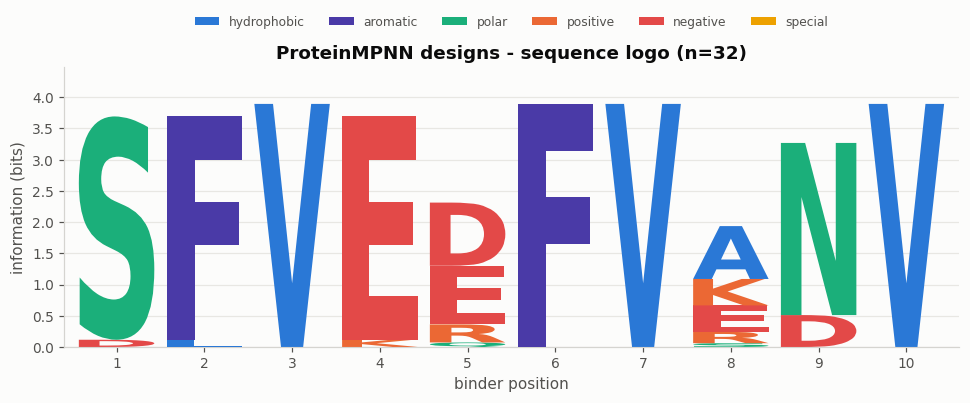

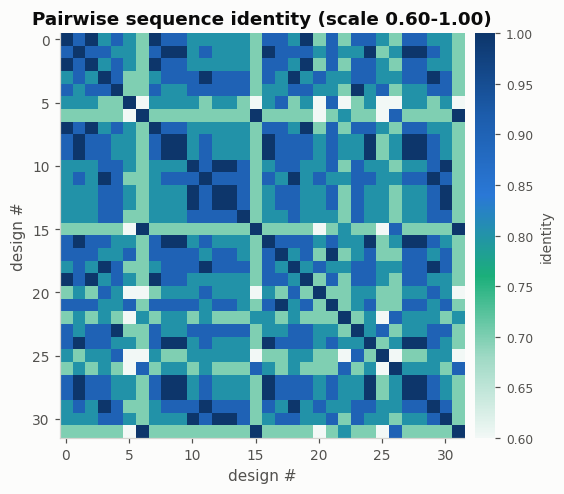

설계 간 평균 identity: 0.82  (범위 0.60 ~ 1.00)


In [ ]:
#@title 5b.  생성된 서열들의 통계
# sequence logo: 각 위치에 어떤 아미노산이 얼마나 자주 오는지를 '글자 크기'로 보여줍니다.
# 글자가 클수록 그 자리에서 그 아미노산이 강하게 선호된다는 뜻입니다.
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch, Patch
from matplotlib.transforms import Affine2D
from matplotlib.font_manager import FontProperties

# 아미노산을 화학적 성질로 묶어 색을 줍니다 (글자 모양만으로는 성질이 안 보이므로)
AA_CLASS = {**{a: "hydrophobic" for a in "AVLIMC"},
            **{a: "aromatic"    for a in "FWY"},
            **{a: "polar"       for a in "STNQ"},
            **{a: "positive"    for a in "KRH"},
            **{a: "negative"    for a in "DE"},
            **{a: "special"     for a in "GP"}}
CLASS_COLOR = {"hydrophobic": PALETTE[0], "aromatic": PALETTE[6], "polar": PALETTE[2],
               "positive":    PALETTE[1], "negative": PALETTE[7], "special": PALETTE[3]}
_LOGO_FONT = FontProperties(family="DejaVu Sans", weight="bold")

def _draw_letter(ax, ch, x, y0, height, width=0.86):
    tp = TextPath((0, 0), ch, size=1, prop=_LOGO_FONT)
    bb = tp.get_extents()
    if bb.width <= 0 or bb.height <= 0: return
    tr = (Affine2D().translate(-bb.x0, -bb.y0)
                    .scale(width / bb.width, height / bb.height)
                    .translate(x - width / 2, y0))
    ax.add_patch(PathPatch(tr.transform_path(tp), zorder=3, edgecolor="none",
                           facecolor=CLASS_COLOR[AA_CLASS.get(ch, "special")]))

def sequence_logo(ax, seqs):
    AA = "ACDEFGHIKLMNPQRSTVWY"; L = len(seqs[0]); n = len(seqs)
    e = (len(AA) - 1) / (2 * np.log(2) * n)
    ymax = 0.0
    for j in range(L):
        col = [s[j] for s in seqs if s[j] in AA]
        p = np.array([col.count(a) for a in AA], float); p /= max(p.sum(), 1)
        nz = p[p > 0]
        total = max(np.log2(len(AA)) + (nz * np.log2(nz)).sum() - e, 0.0)
        y = 0.0
        for k in np.argsort(p):          # 작은 것부터 아래에 쌓기
            h = p[k] * total
            if h > 0.005: _draw_letter(ax, AA[k], j + 1, y, h)
            y += h
        ymax = max(ymax, y)
    ax.set_xlim(0.4, L + 0.6); ax.set_ylim(0, max(ymax * 1.15, 0.5))
    ax.set_xticks(range(1, L + 1))
    ax.set_ylabel("information (bits)")
    return ymax

# ---- 그림 1: sequence logo ----
fig, ax = plt.subplots(figsize=(10.5, 3.3))
ymax = sequence_logo(ax, mpnn_seqs)
ax.set_xlabel("binder position")
ax.set_title(f"ProteinMPNN designs - sequence logo (n={len(mpnn_seqs)})")
ax.legend(handles=[Patch(facecolor=c, label=k) for k, c in CLASS_COLOR.items()],
          frameon=False, fontsize=8, labelcolor=INK2, ncol=6,
          loc="lower center", bbox_to_anchor=(0.5, 1.10))
style_axes(ax)
plt.show()

# ---- 그림 2: 설계들끼리 얼마나 다른가 ----
n = len(mpnn_seqs)
I = np.array([[np.mean([x == y for x, y in zip(a, b)]) for b in mpnn_seqs] for a in mpnn_seqs])
off_all = I[np.triu_indices(n, 1)]
lo = max(0.0, np.floor(off_all.min() * 20) / 20)      # 0.05 단위로 내림
fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.imshow(I, cmap=CMAP_SEQ_MID, vmin=lo, vmax=1, interpolation="nearest")
ax.set_xlabel("design #"); ax.set_ylabel("design #")
ax.set_title(f"Pairwise sequence identity (scale {lo:.2f}-1.00)")
bare_colorbar(fig, im, ax, "identity")
style_axes(ax, grid_axis=None)
fig.tight_layout(); plt.show()

off = I[np.triu_indices(n, 1)]
print(f"설계 간 평균 identity: {off.mean():.2f}  (범위 {off.min():.2f} ~ {off.max():.2f})")

글자가 크고 하나만 보이는 자리 = backbone이 그 아미노산을 강하게 요구하는 위치  
글자가 작고 여러 개 쌓인 자리   = 자유도가 큰 위치 (대개 용매에 노출된 면)

## 6. 검증 — 이 실습에서 가장 중요한 단계
---

여기까지는 **설계 도구가 자기 스스로를 평가한** 상태입니다.  
AfDesign이 "잘 됐다"고 말한 것을 AfDesign의 점수로 확인하면 **self-consistency bias** 문제가 있을 수 있습니다.  
<br>
이 문제를 해결하기 위해서

> **설계에 쓴 정보를 지우고, 서열만 가지고 구조를 다시 예측합니다.**
> 그리고 원래 설계했던 모양으로 되돌아오는지 봅니다.

되돌아온 정도를 재는 값이 **scRMSD** (self-consistency RMSD)입니다.


| 지표 | 통과 기준 (관례) | 의미 |
|---|---|---|
| **scRMSD** | < 2 Å | 서열이 의도한 모양을 실제로 encode하는가 |
| **pLDDT** | > 0.7 | 구조가 확신 있게 접히는가 |
| **ipTM** | > 0.5 | 표적에 대한 배치가 확신 있는가 |



이때 설계 서열을 **무작위로 섞은 서열**을 만들어 똑같은 검증을 과정을 거칩니다.
아미노산 조성은 완전히 같고 순서만 다르므로, 조성 때문에 통과하는 게 아님을 보일 수 있습니다.

### self-consistency 검증의 구조

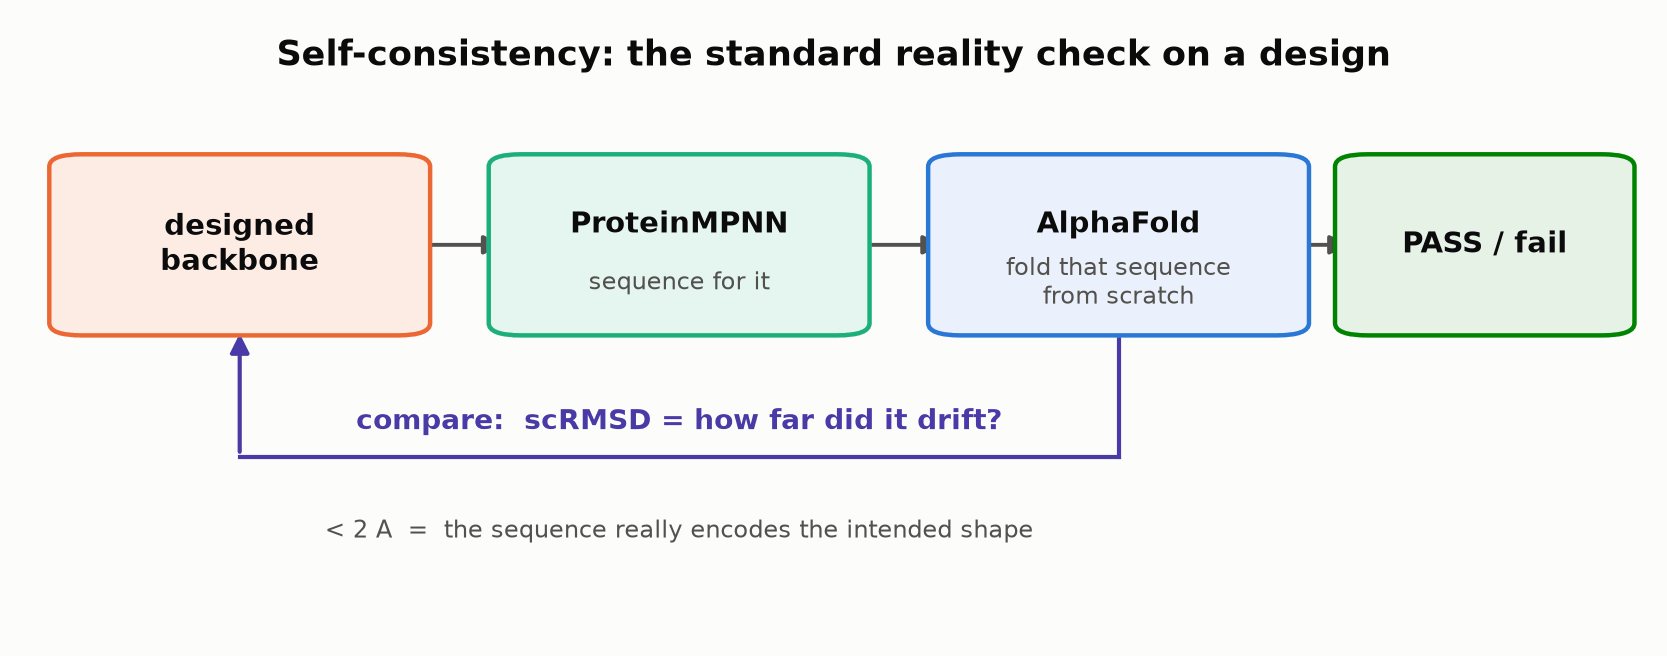

핵심: 예측 단계에서는 **설계할 때 쓴 Target에 대한 정보를 전혀 주지 않습니다.**  
서열만 주고 처음부터 접게 한 뒤, 원래 설계했던 모양으로 돌아오는지를 봅니다.

In [ ]:
#@title 6a. AlphaFold 재예측으로 검증 (+ shuffled sequence)
import random
clear_mem()

# 검증용 모델: 설계 복합체를 '정답 backbone'으로 두고, 서열만 바꿔가며 재예측합니다.
# binder_chain을 지정하면 rmsd(=scRMSD)가 loss/log에 함께 계산됩니다.
val_model = mk_afdesign_model(protocol="binder", data_dir=".",
                              num_recycles=1, recycle_mode="last")
val_model.prep_inputs(pdb_filename="design.pdb", chain="A", binder_chain="B")
print("검증 모델 준비 완료 | lengths:", val_model._lengths)

# shuffled sequence: 설계 서열을 섞기만 한 것 (조성 동일, 순서만 다름)
rng = random.Random(RANDOM_SEED)
shuffled = ["".join(rng.sample(list(s), len(s))) for s in mpnn_seqs[:3]]

candidates = ([("AfDesign", AFDESIGN_SEQ)] +
              [("MPNN", s) for s in mpnn_seqs] +
              [("shuffled (control)", s) for s in shuffled])

rows = []
_t0 = time.time()
for kind, s in candidates:
    val_model.predict(seq=s, num_recycles=1, num_models=1, verbose=False)
    g = val_model.aux["log"]
    r, p, i = float(g["rmsd"]), float(g["plddt"]), float(g["i_ptm"])
    rows.append({"kind": kind, "sequence": s,
                 "scRMSD": round(r, 2), "pLDDT": round(p, 3), "ipTM": round(i, 3),
                 "pass": bool(r < PASS_RMSD and p > PASS_PLDDT and i > PASS_IPTM)})
val_df = pd.DataFrame(rows)
print(f"{len(candidates)}개 서열 검증: {time.time()-_t0:.0f}초 ")
# 후보가 많으므로 좋은 것부터 정렬해서 보여줍니다 (대조군은 맨 아래로).
_is_ctrl = (val_df["kind"] == "shuffled (control)").astype(int)
val_df = (val_df.assign(_c=_is_ctrl)
                .sort_values(["_c", "scRMSD"], ascending=[True, True])
                .drop(columns="_c").reset_index(drop=True))
print("상위 12개:")
display(val_df.head(12))
print("\n대조군:")
display(val_df[val_df.kind == "shuffled (control)"])

n_pass_design = int(val_df[val_df.kind != "shuffled (control)"]["pass"].sum())
n_design = int((val_df.kind != "shuffled (control)").sum())
n_pass_ctrl = int(val_df[val_df.kind == "shuffled (control)"]["pass"].sum())
print(f"Designed Sequence : {n_pass_design}/{n_design}")
print(f"Shuffled Sequence : {n_pass_ctrl}/{len(shuffled)} ")

검증 모델 준비 완료 | lengths: [np.int64(90), np.int64(10)]
36개 서열 검증: 80초 
상위 12개:


,kind,sequence,scRMSD,pLDDT,ipTM,pass
0,MPNN,SFVEDFVKNV,0.42,0.866,0.824,True
1,MPNN,SFVEDFVKNV,0.42,0.866,0.824,True
2,MPNN,SFVKDFVENV,0.42,0.861,0.822,True
3,MPNN,SFVEDFVKNV,0.42,0.866,0.824,True
4,MPNN,SFVEDFVKNV,0.42,0.866,0.824,True
5,MPNN,SFVEQFVADV,0.43,0.892,0.846,True
6,MPNN,SFVEDFVANV,0.44,0.868,0.830,True
7,MPNN,SFVEDFVANV,0.44,0.868,0.830,True
8,MPNN,SFVEDFVANV,0.44,0.868,0.830,True
9,MPNN,SFVEDFVANV,0.44,0.868,0.830,True



대조군:


,kind,sequence,scRMSD,pLDDT,ipTM,pass
33,shuffled (control),VVSVDEFFNK,4.95,0.662,0.632,False
34,shuffled (control),VEVAFSVNDF,5.64,0.389,0.237,False
35,shuffled (control),FVFEDSVNVK,11.67,0.367,0.206,False


Designed Sequence : 32/33
Shuffled Sequence : 0/3 


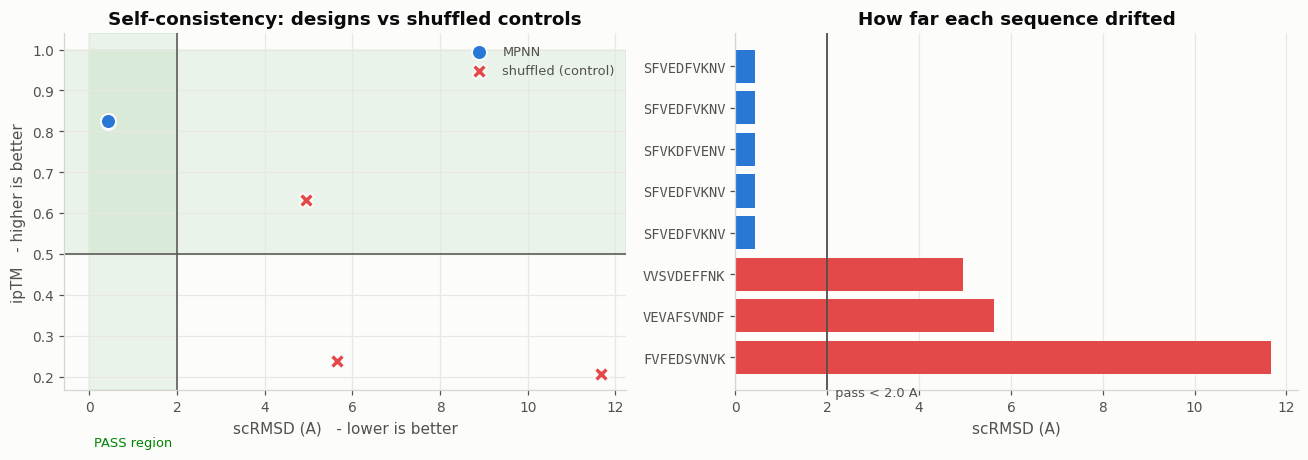

In [ ]:
#@title 6b. [그림] 검증 결과 — 설계 vs 대조군
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.3))
groups = [("AfDesign", PALETTE[1], "o"), ("MPNN", PALETTE[0], "o"),
          ("shuffled (control)", PALETTE[7], "X")]

val_df = val_df.iloc[[0,1,2,3,4,-3,-2,-1]]

ax = axes[0]
ax.axvspan(0, PASS_RMSD, color=PALETTE[5], alpha=0.07, zorder=0)
ax.axhspan(PASS_IPTM, 1.0, color=PALETTE[5], alpha=0.07, zorder=0)
for name, col, mk in groups:
    sub = val_df[val_df.kind == name]
    if len(sub):
        ax.scatter(sub["scRMSD"], sub["ipTM"], s=95, c=col, marker=mk,
                   edgecolor=SURFACE, linewidth=1.2, label=name, zorder=3)
ax.axvline(PASS_RMSD, color=INK2, linewidth=1)
ax.axhline(PASS_IPTM, color=INK2, linewidth=1)
ax.set_xlabel("scRMSD (A)   - lower is better")
ax.set_ylabel("ipTM   - higher is better")
ax.set_title("Self-consistency: designs vs shuffled controls")
ax.legend(frameon=False, fontsize=8.5, labelcolor=INK2, loc="upper right")
style_axes(ax, grid_axis="both")
ax.text(PASS_RMSD*0.5, 0.03, "PASS region", fontsize=8.5, color=PALETTE[5], ha="center")

ax = axes[1]
order = val_df.sort_values("scRMSD").reset_index(drop=True)
cols = [PALETTE[7] if k == "shuffled (control)" else
        (PALETTE[1] if k == "AfDesign" else PALETTE[0]) for k in order["kind"]]
ax.barh(np.arange(len(order)), order["scRMSD"], color=cols, linewidth=0)
ax.axvline(PASS_RMSD, color=INK2, linewidth=1.2)
ax.text(PASS_RMSD, len(order)-0.3, f"  pass < {PASS_RMSD} A", fontsize=8.5, color=INK2, va="top")
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels(order["sequence"], fontsize=7.5, family="monospace")
ax.invert_yaxis()
ax.set_xlabel("scRMSD (A)"); ax.set_title("How far each sequence drifted")
style_axes(ax, grid_axis="x")
fig.tight_layout(); plt.show()

**Designed:** 왼쪽 위   
**Shuffled:** 오른쪽 아래로 갈라지면 성공입니다  

저희 설계는 낮은 RMSD/높은 ipTM을 보였습니다.
Shuffled sequence는 오른쪽 아래로 밀려납니다.   
Designed sequence와 Shuffled sequence가 겹친다면 필터가 구분을 못 하고 있다는 뜻입니다.

## 7. 채점 — 우리가 무엇을 재발견했는가
---



이제 봉인해 뒀던 **정답 펩타이드 서열**을 꺼냅니다.

p53가 MDM2/MDMX에 결합하는 방식은 잘 알려져 있습니다. p53의 나선에서
**세 개의 큰 소수성 곁사슬(Phe, Trp, Leu)** 이 표적 포켓 세 곳에 박히는 구조입니다.
이 삼중자가 결합의 핵심이라 "hot-spot triad"라고 부릅니다.

우리는 이 서열을 **한 번도 보지 않고** 설계했습니다.
그렇다면 설계된 서열에도 같은 종류의 곁사슬이 같은 간격으로 나타났을까요?

In [ ]:
#@title 7a. 정답 펩타이드와 비교
NATIVE_PEPTIDE=chain_sequence(structure, PEPTIDE_CHAIN)
print("정답(p53 유래) :", NATIVE_PEPTIDE)
print("AfDesign       :", AFDESIGN_SEQ)
for s in mpnn_seqs[:5]:
    print("MPNN           :", s)

BIG_HYDROPHOBIC = set("FWYLIMV")
def motif_profile(seq):
    # 큰 소수성 잔기 자리를 '#'로 표시해 패턴을 눈으로 비교합니다.
    return "".join("#" if a in BIG_HYDROPHOBIC else "." for a in seq)

print("\n큰 소수성 잔기(F/W/Y/L/I/M/V) 위치 패턴  ('#' = 소수성)")
print(f"  {'native':<10} {NATIVE_PEPTIDE:<16} {motif_profile(NATIVE_PEPTIDE)}")
print(f"  {'AfDesign':<10} {AFDESIGN_SEQ:<16} {motif_profile(AFDESIGN_SEQ)}")
for i, s in enumerate(mpnn_seqs[:5]):
    print(f"  {'MPNN '+str(i):<10} {s:<16} {motif_profile(s)}")

frac_native = sum(a in BIG_HYDROPHOBIC for a in NATIVE_PEPTIDE) / len(NATIVE_PEPTIDE)
frac_design = np.mean([sum(a in BIG_HYDROPHOBIC for a in s) / len(s) for s in mpnn_seqs])
print(f"\n큰 소수성 잔기 비율:  정답 {frac_native:.0%}  vs  설계 평균 {frac_design:.0%}")

정답(p53 유래) : LTFEYWAQSAA
AfDesign       : EFVQWFVDNI
MPNN           : SFVEDFVKNV
MPNN           : SFVEDFVANV
MPNN           : SFVEDFVKNV
MPNN           : SFVEEFVANV
MPNN           : SFVEEFVKNV

큰 소수성 잔기(F/W/Y/L/I/M/V) 위치 패턴  ('#' = 소수성)
  native     LTFEYWAQSAA      #.#.##.....
  AfDesign   EFVQWFVDNI       .##.###..#
  MPNN 0     SFVEDFVKNV       .##..##..#
  MPNN 1     SFVEDFVANV       .##..##..#
  MPNN 2     SFVEDFVKNV       .##..##..#
  MPNN 3     SFVEEFVANV       .##..##..#
  MPNN 4     SFVEEFVKNV       .##..##..#

큰 소수성 잔기 비율:  정답 36%  vs  설계 평균 50%


설계 서열에 W/F/Y와 L/I가 반복적으로 나타난다면
모델이 '이 포켓은 큰 소수성 곁사슬을 원한다'를 스스로 알아냈다는 뜻입니다.

정답과 서열이 다르다'가 곧 '설계가 틀렸다'는 뜻은 아닙니다.
봐야 할 것은 서열 일치가 아니라 '같은 종류의 곁사슬이 같은 간격으로 배치되었는가'입니다.

In [ ]:
#@title 7b. 최종 후보 정리 + 저장
final = val_df[(val_df.kind != "shuffled (control)") & (val_df["pass"])].copy()
final = final.sort_values(["scRMSD", "ipTM"], ascending=[True, False]).reset_index(drop=True)

print(f"최종 통과 후보: {len(final)}개\n")
display(final)

final.to_csv("designed_binders.csv", index=False)
if len(final):
    with open("designed_binders.fasta", "w") as f:
        for i, row in final.iterrows():
            f.write(f">MDMX_binder_{i+1}_rmsd{row.scRMSD:.2f}_iptm{row.ipTM:.2f}\n{row.sequence}\n")
    print(open("designed_binders.fasta").read())
else:
    print("통과한 후보가 없습니다. RANDOM_SEED를 바꾸거나 FAST_MODE=False로 다시 시도하세요.")

print("saved: designed_binders.csv, designed_binders.fasta")

최종 통과 후보: 5개



,kind,sequence,scRMSD,pLDDT,ipTM,pass
0,MPNN,SFVEDFVKNV,0.42,0.866,0.824,True
1,MPNN,SFVEDFVKNV,0.42,0.866,0.824,True
2,MPNN,SFVEDFVKNV,0.42,0.866,0.824,True
3,MPNN,SFVEDFVKNV,0.42,0.866,0.824,True
4,MPNN,SFVKDFVENV,0.42,0.861,0.822,True


>MDMX_binder_1_rmsd0.42_iptm0.82
SFVEDFVKNV
>MDMX_binder_2_rmsd0.42_iptm0.82
SFVEDFVKNV
>MDMX_binder_3_rmsd0.42_iptm0.82
SFVEDFVKNV
>MDMX_binder_4_rmsd0.42_iptm0.82
SFVEDFVKNV
>MDMX_binder_5_rmsd0.42_iptm0.82
SFVKDFVENV

saved: designed_binders.csv, designed_binders.fasta


In [ ]:
# @title 통합 3D 구조 시각화 (Target + Binder + Reference Peptide)
import py3Dmol

view = py3Dmol.view(width=880, height=520)
view.addModel(open("design.pdb").read(), "pdb")
view.addModel(open(pdb_file).read(), "pdb")

view.setStyle({}, {})
view.setStyle({"model": 0, "chain": "A"}, {"cartoon": {"color": "lightgray", "opacity": 0.5}})
view.addSurface(py3Dmol.VDW, {"opacity": 0.70, "color": "#d8d8d8"}, {"model": 0, "chain": "A"})
view.setStyle({"model": 0, "chain": "B"}, {"cartoon": {"color": "#2a78d6"}})
PEPTIDE_CHAIN = globals().get("PEPTIDE_CHAIN", "B")
view.setStyle({"model": 1, "chain": PEPTIDE_CHAIN}, {"cartoon": {"color": "orange"}})

view.zoomTo({"model": 0, "chain": "B"})
view.show()

print("회색 표면 = Target (MDMX)")
print("파란색 = 설계된 Binder (design.pdb)")
print(f"주황색 = Original Peptide ({pdb_file})")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

회색 표면 = Target (MDMX)
파란색 = 설계된 Binder (design.pdb)
주황색 = Original Peptide (4N5T.pdb)


앞의 3D 그림(정답 복합체)과 나란히 비교해 보세요.
  - 같은 구멍에 곁사슬이 들어갔나요?
  - 나선이 같은 방향으로 누워 있나요?

## 8. 한계와 다음 단계
------

이 노트북은 계산만으로 끝납니다. 실제로는 다음이 남아 있습니다.

**1. 더 독립적인 검증**
우리 검증도 결국 AlphaFold입니다. 설계와 검증이 **같은 모델**이라는 한계가 남습니다.
실무에서는 ColabFold/AF-Multimer를 **별도 실행**하거나, ESMFold·Boltz 등 다른 계열 모델로 교차 검증합니다.
→ https://github.com/sokrypton/ColabFold

**2. 여러 trajectory**
설계는 seed에 따라 결과가 크게 달라집니다. 실제 연구에서는 **수십~수천 개**를 돌리고
통과율 상위 몇 개만 남깁니다. 오늘은 1개만 돌렸습니다.

**3. 물리적 타당성**
AlphaFold는 결합 **자유에너지**를 계산하지 않습니다. 용해도, 응집, 안정성, 면역원성,
합성 난이도는 전혀 보지 않습니다. MD나 Rosetta 계열 에너지 평가가 추가로 필요합니다.

**4. 결과가 실행마다 다르다 (중요)**
같은 `RANDOM_SEED`로 돌려도 결과가 달라집니다. seed 설정이 잘못된 게 아니라,
**GPU 부동소수점 연산 순서가 실행마다 미세하게 달라지기 때문**입니다.
semigreedy 단계는 loss 차이의 *부호*로 돌연변이를 채택/기각하므로,
아주 작은 수치 차이가 판정 하나를 뒤집으면 이후 궤적이 완전히 갈라집니다.
따라서 **한 번의 결과로 결론을 내리면 안 됩니다.** 여러 번 돌려 분포를 보세요.

**5.실험**
최종적으로는 SPR/ITC로 결합을 측정하고 세포 실험으로 기능을 확인해야 합니다.
계산은 **실험할 후보의 순위를 매기는 도구**이지 결론이 아닙니다.



# 학생 과제  (후보)
-------
1. **같은 `RANDOM_SEED`로** 설계 셀을 2번 돌려라. 결과가 같은가, 다른가?
   다르다면 그 이유는 무엇인가? (힌트: 한계 4번)
   이런 파이프라인에서 "재현 가능하다"는 말은 무엇을 의미해야 하는가?
2. `RANDOM_SEED`를 3개 이상 바꿔 반복하고, 설계 ipTM과 통과 후보 수의 **분포**를 보고하라.
   평균만 쓰지 말고 최소~최대 범위를 함께 제시하라.
3. `BINDER_LENGTH`를 **10 / 14 / 20**으로 바꿔 비교하라.
   길수록 좋은가? 정답 펩타이드 길이(11-mer)와 비교해 논하라.
4. 어떤 서열이 **scRMSD는 낮은데 ipTM은 낮게** 나왔다면 무슨 상황인가?
   반대로 **pLDDT는 높은데 scRMSD가 큰** 경우는?
5. `N_HOTSPOT`을 1~2개로 줄이거나 hotspot을 아예 주지 않고(`hotspot=None`) 설계해 보라.
   binder가 어디에 붙는가? hotspot의 역할을 실험적으로 보여라.
6. `MPNN_TEMPERATURE`를 0.1 → 0.3으로 올려라.
   서열 다양성(pairwise identity)과 통과율은 어떻게 달라지는가? 트레이드오프를 논하라.
7. 표적을 바꿔 보라. ColabDesign 공식 예제의 다른 PDB나, 여러분이 관심 있는 PPI를 골라
   같은 파이프라인을 적용하라. 표적 크기가 커지면 무엇이 문제가 되는가?

## 용어 정리
------

| 용어 | 뜻 |
|---|---|
| **PPI** | 단백질–단백질 상호작용 |
| **epitope / hotspot** | 결합 부위 / 결합에 특히 크게 기여하는 residue |
| **hallucination** | 원하는 성질이 나오도록 입력(서열)을 거꾸로 최적화하는 것 |
| **inverse folding** | 구조를 주고 서열을 찾는 문제 (ProteinMPNN) |
| **pLDDT** | residue별 국소 구조 신뢰도 (0~100, 높을수록 좋음) |
| **PAE** | residue 쌍의 상대 위치 오차 예상값 (Å, 낮을수록 좋음) |
| **pTM / ipTM** | 전체 / 사슬 간 구조 정확도 예측 (0~1, 높을수록 좋음) |
| **scRMSD** | 설계한 모양과, 서열만으로 다시 접은 모양의 차이 (Å) |
| **self-consistency** | 설계 → 서열 → 재예측이 서로 일치하는지 보는 검증 |
| **self-consistency bias** | 설계에 쓴 모델로 평가해서 생기는 낙관적 편향 |
| **negative control** | 일부러 나쁘게 만든 입력. 필터가 작동하는지 보이는 장치 |

## 참고자료
------

**구조 / 표적**
- RCSB 4N5T: https://www.rcsb.org/structure/4N5T
- p53–MDM2/MDMX 저해제 리뷰: Khoo, Verma & Lane (2014) *Nat Rev Drug Discov*

**도구 (이 노트북이 기반한 공식 예제)**
- ColabDesign: https://github.com/sokrypton/ColabDesign
  - peptide binder design 예제: `af/examples/peptide_binder_design.ipynb`
  - ProteinMPNN + AlphaFold 검증 예제: `mpnn/examples/proteinmpnn_in_jax.ipynb`
- ColabFold (독립 검증용): https://github.com/sokrypton/ColabFold
- ProteinMPNN 원본: https://github.com/dauparas/ProteinMPNN

**개념 논문**
- Jumper et al. (2021) *AlphaFold*, Nature — pLDDT/PAE 정의
- Dauparas et al. (2022) *ProteinMPNN*, Science
- Anishchenko et al. (2021) *De novo protein design by deep network hallucination*, Nature
- Watson et al. (2023) *RFdiffusion*, Nature — self-consistency 필터의 표준적 사용례

---

**이 노트북이 만드는 파일**

| 파일 | 내용 |
|---|---|
| `target.pdb` | 설계 입력 (MDMX만) |
| `design.pdb` | AfDesign 결과 복합체 |
| `designed_binders.csv` | 검증 지표가 붙은 최종 후보 |
| `designed_binders.fasta` | 통과 후보 서열 |